# Using the Perceptron Model to Detect Counterfeit Banknotes

In this notebook, we apply the perceptron model to explore if we can predict whether or not images depict real or counterfeit banknotes. This [Banknote Authentication dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) comes from UC Irvine's Machine Learning Repository.

This dataset was collected by researchers at the University of Applied Sciences in Ostwestfalen-Lippe, Germany, as part of work on automated currency verification systems.

Each banknote image was captured using an industrial camera under controlled lighting, and a Wavelet Transform was applied to the greyscale image to extract four statistical descriptors of the spatial frequency content. These four numbers (variance, skewness, kurtosis, and entropy of the wavelet sub-bands) serve as compact signatures that distingush genuine notes from forgeries.

The dataset contains 1,372 samples (762 genuine, 610 forged) with four continuous features and a binary label.

**Features:**
| **Feature** | **Type** | **Description** |
|---|---|---|
| Variance | Continuous | Variance of wavelet-transformed image |
| Skewness | Continuous | Skewness of wavelet-transformed image |
| Kurtosis | Continuous | Kurtosis of wavelet-transformed image |
| Entropy | Continuous | Entropy of wavelet-transformed image |

**Target:** class — 0 (genuine) or 1 (forged); encoded as **+1** (genuine) / **−1** (forged) for the Perceptron

## Load and Explore Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    Perceptron,
    StandardScaler,
    train_test_split,
    classification_metrics,
)

np.random.seed(42)

In [5]:
# Load data and assign features and target
df = pd.read_csv("data_banknote_authentication.txt")

df.columns = ["Variance", "Skewness", "Kurtosis", "Entropy", "Class"]

In [8]:
X = df.drop(columns = "Class")
y = df["Class"]


print(f"Class balance:  genuine (0): {(y == 0).sum()}   forged (1): {(y == 1).sum()}")
df.head()

Class balance:  genuine (0): 761   forged (1): 610


,Variance,Skewness,Kurtosis,Entropy,Class
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [9]:
# Descriptive statistics
X.describe().round(3)

,Variance,Skewness,Kurtosis,Entropy
count,1371.000,1371.000,1371.000,1371.000
mean,0.431,1.917,1.401,-1.192
std,2.842,5.868,4.310,2.102
min,-7.042,-13.773,-5.286,-8.548
25%,-1.775,-1.711,-1.553,-2.417
50%,0.496,2.313,0.617,-0.587
75%,2.815,6.813,3.182,0.395
max,6.825,12.952,17.927,2.450


---

The summary statistics table reveals significant scale differences. Variance spans roughly −7 to 7, Skewness spans roughly −14 to 13, Kurtosis spans roughly 5 to 18, and Entropy spans roughly −8 to 2. The wide range of scales, along with their negative lower bounds, makes standardization necessary for gradient-based training.

---

## Data Preprocessing

The `Perceptron` in `ml_package` expects labels **+1** and **−1**, not 0/1. We encode genuine notes as +1 and forged notes as −1 to match the perceptron's MSE-based gradient update rule.

In [16]:
y = np.where(y == 0, 1, -1).astype(float)
print(f"Label distribution:  +1 (genuine): {(y==1).sum()}   -1 (forged): {(y==-1).sum()}")

X_arr = X.values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Label distribution:  +1 (genuine): 761   -1 (forged): 610

Train: 1096  |  Test: 275


## Final Model

For purposes of this example, and to stay true to the original perceptron model, we will proceed by specifying a perceptron model with a unit-step function. Other activation functions are available to use, and a good extension of this notebook would be comparing different activations.

---

In [18]:
model = Perceptron(activation = "unitstep")
model.train(X_train_s, y_train, eta=0.01, epochs=1000)

print(f"  Accuracy  : {model.accuracy(X_test_s, y_test):.4f}")
print(f"  Precision : {model.precision(X_test_s, y_test):.4f}")
print(f"  Recall    : {model.recall(X_test_s, y_test):.4f}")
print(f"  F1 Score  : {model.f1_score(X_test_s, y_test):.4f}")

  Accuracy  : 0.9927
  Precision : 0.9935
  Recall    : 0.9935
  F1 Score  : 0.9935


---

Our perceptron model achieved nearly perfect accuracy on the dataset! A primary reason for this is that the classes are highly linearly separable, allowing our model to find a near-perfect boundary. In the context of the dataset, our model's strong accuracy can allow bank authenticators to take pictures of bank notes and classify them as fradulent or not simply based on the details of the image.

Below, the confusion matrix shows the details of the predictions versus the actual class labels.

---

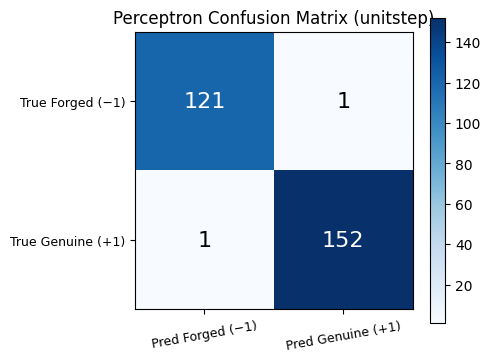


True  Positives (genuine correctly identified) : 152
True  Negatives (forged  correctly rejected)   : 121
False Positives (forged  passed as genuine)    : 1  ← costly error
False Negatives (genuine wrongly rejected)     : 1


In [20]:
cm = model.confusion_matrix(X_test_s, y_test)

# Note: our y encodes genuine=+1, forged=-1
# confusion_matrix rows/cols: index 0 → class -1 (forged), index 1 → class +1 (genuine)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
tick_labels = ["Forged (−1)", "Genuine (+1)"]
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels([f"Pred {t}" for t in tick_labels], fontsize=9, rotation=10)
ax.set_yticklabels([f"True {t}" for t in tick_labels], fontsize=9)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() * 0.6 else "black")
plt.colorbar(im, ax=ax)
ax.set_title(f"Perceptron Confusion Matrix ({"unitstep"})")
plt.tight_layout()
plt.show()

tn, fp = cm[0, 0], cm[0, 1]
fn, tp = cm[1, 0], cm[1, 1]
print(f"\nTrue  Positives (genuine correctly identified) : {tp}")
print(f"True  Negatives (forged  correctly rejected)   : {tn}")
print(f"False Positives (forged  passed as genuine)    : {fp}  ← costly error")
print(f"False Negatives (genuine wrongly rejected)     : {fn}")

---

Overall, this dataset revealed how simple yet powerful the perceptron model is. A single neuron with four inputs, trained in seconds, was able to reliably flag counterfeit banknotes when coupled with the appropriate image-processing front end.

---